In [89]:
import pandas as pd
import numpy as np
import matplotlib as plt
import seaborn as sns
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, accuracy_score, f1_score
from sklearn.preprocessing import Normalizer
import xgboost as xgb
from xgboost import XGBClassifier

# Load the data

In [90]:
# Read Data
df = pd.read_csv("dataset/cleaned_training_data.csv")

In [91]:
df.head()

,label,text,text_clean,text_no_stopwords,text_lemmatized
0,0,donald trump sends out embarrassing new year‚s...,donald trump sends out embarrassing new year e...,donald trump sends embarrassing new year eve m...,donald trump sends embarrassing new year eve m...
1,0,drunk bragging trump staffer started russian c...,drunk bragging trump staffer started russian c...,drunk bragging trump staffer started russian c...,drunk bragging trump staffer started russian c...
2,0,sheriff david clarke becomes an internet joke ...,sheriff david clarke becomes an internet joke ...,sheriff david clarke becomes internet joke thr...,sheriff david clarke becomes internet joke thr...
3,0,trump is so obsessed he even has obama‚s name ...,trump is so obsessed he even has obama name co...,trump obsessed even obama name coded website i...,trump obsessed even obama name coded website i...
4,0,pope francis just called out donald trump duri...,pope francis just called out donald trump duri...,pope francis called donald trump christmas speech,pope francis called donald trump christmas speech


In [92]:
df.shape

(32203, 5)

# Split the dataset

In [93]:
# Split into features and labels

X = df['text_lemmatized']
y = df['label']
print(X)
print(y)

0        donald trump sends embarrassing new year eve m...
1        drunk bragging trump staffer started russian c...
2        sheriff david clarke becomes internet joke thr...
3        trump obsessed even obama name coded website i...
4        pope francis called donald trump christmas speech
                               ...                        
32198              tear rain thai gather late king funeral
32199    pyongyang university need non teacher travel b...
32200    philippine president duterte visit japan ahead...
32201                  japan abe may election many want pm
32202    demoralized divided inside catalonia police force
Name: text_lemmatized, Length: 32203, dtype: object
0        0
1        0
2        0
3        0
4        0
        ..
32198    1
32199    1
32200    1
32201    1
32202    1
Name: label, Length: 32203, dtype: int64


In [94]:
# Split data into training and testing set

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"X original shape: {X.shape}")
print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")

print(f"y original shape: {y.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

X original shape: (32203,)
X_train shape: (25762,)
X_test shape: (6441,)
y original shape: (32203,)
y_train shape: (25762,)
y_test shape: (6441,)


# Bag of Words

Different parameters of CountVectorizer will be evaluated, to assess the best performing for this dataset.

In [116]:
# Repeat base model evaluation
vectorizer = CountVectorizer()
X_train_bow = vectorizer.fit_transform(X_train)
X_test_bow = vectorizer.transform(X_test)

print("Vocabulary size:", len(vectorizer.vocabulary_))
print("Feature names:", vectorizer.get_feature_names_out())
print("Matrix shape:", X_train_bow.shape)

normalizer = Normalizer(norm="l2")

X_train_bow_normalized = normalizer.fit_transform(X_train_bow)
X_test_bow_normalized = normalizer.transform(X_test_bow)

xgb_bow = XGBClassifier(eval_metric="logloss")

xgb_bow.fit(X_train_bow_normalized, y_train)

y_pred_xgb_bow = xgb_bow.predict(X_test_bow_normalized)

print("\n XGBoost with CountVectorizer")
print("Accuracy:", accuracy_score(y_test, y_pred_xgb_bow))
print(classification_report(y_test, y_pred_xgb_bow))
print(confusion_matrix(y_test, y_pred_xgb_bow))

Vocabulary size: 14867
Feature names: ['00' '0045' '0111' ... 'zuma' 'zummar' 'zurich']
Matrix shape: (25762, 14867)

 XGBoost with CountVectorizer
Accuracy: 0.895668374476013
              precision    recall  f1-score   support

           0       0.94      0.84      0.89      3239
           1       0.86      0.95      0.90      3202

    accuracy                           0.90      6441
   macro avg       0.90      0.90      0.90      6441
weighted avg       0.90      0.90      0.90      6441

[[2726  513]
 [ 159 3043]]


Use unigrams and bigrams

In [96]:
# Use unigrams and bigrams
vectorizer_2 = CountVectorizer(ngram_range=(1,2))
X_train_bow_2 = vectorizer_2.fit_transform(X_train)
X_test_bow_2 = vectorizer_2.transform(X_test)

print("Vocabulary size:", len(vectorizer_2.vocabulary_))
print("Feature names:", vectorizer_2.get_feature_names_out())
print("Matrix shape:", X_train_bow_2.shape)

# Normalize the data
normalizer = Normalizer(norm="l2")

X_train_bow_normalized_2 = normalizer.fit_transform(X_train_bow_2)
X_test_bow_normalized_2 = normalizer.transform(X_test_bow_2)

# XGBoost Classifier
xgb_bow = XGBClassifier(eval_metric="logloss")

xgb_bow.fit(X_train_bow_normalized_2, y_train)

y_pred_xgb_bow_2 = xgb_bow.predict(X_test_bow_normalized_2)

print("\n XGBoost with CountVectorizer")
print("Accuracy:", accuracy_score(y_test, y_pred_xgb_bow_2))
print(classification_report(y_test, y_pred_xgb_bow_2))
print(confusion_matrix(y_test, y_pred_xgb_bow_2))

Vocabulary size: 150430
Feature names: ['00' '00 est' '0045' ... 'zummar kurdistan' 'zurich' 'zurich evacuated']
Matrix shape: (25762, 150430)

 XGBoost with CountVectorizer
Accuracy: 0.8574755472752679
              precision    recall  f1-score   support

           0       0.90      0.81      0.85      3239
           1       0.83      0.90      0.86      3202

    accuracy                           0.86      6441
   macro avg       0.86      0.86      0.86      6441
weighted avg       0.86      0.86      0.86      6441

[[2629  610]
 [ 308 2894]]


Using unigrams and bigrams worsened the model's performanced when comapred to using only unigrams (base model with 0.90 accuracy).

Use only bigrams

In [97]:
# Use bigrams
vectorizer_3 = CountVectorizer(ngram_range=(2,2))
X_train_bow_3 = vectorizer_3.fit_transform(X_train)
X_test_bow_3 = vectorizer_3.transform(X_test)

print("Vocabulary size:", len(vectorizer_3.vocabulary_))
print("Feature names:", vectorizer_3.get_feature_names_out())
print("Matrix shape:", X_train_bow_3.shape)

# Normalize the data
normalizer = Normalizer(norm="l2")

X_train_bow_normalized_3 = normalizer.fit_transform(X_train_bow_3)
X_test_bow_normalized_3 = normalizer.transform(X_test_bow_3)

# XGBoost Classifier
xgb_bow = XGBClassifier(eval_metric="logloss")

xgb_bow.fit(X_train_bow_normalized_3, y_train)

y_pred_xgb_bow_3 = xgb_bow.predict(X_test_bow_normalized_3)

print("\n XGBoost with CountVectorizer")
print("Accuracy:", accuracy_score(y_test, y_pred_xgb_bow_3))
print(classification_report(y_test, y_pred_xgb_bow_3))
print(confusion_matrix(y_test, y_pred_xgb_bow_3))

Vocabulary size: 135563
Feature names: ['00 est' '0045 gmt' '0111 gmt' ... 'zuma successor' 'zummar kurdistan'
 'zurich evacuated']
Matrix shape: (25762, 135563)

 XGBoost with CountVectorizer
Accuracy: 0.6567303213786679
              precision    recall  f1-score   support

           0       0.91      0.35      0.51      3239
           1       0.60      0.96      0.74      3202

    accuracy                           0.66      6441
   macro avg       0.75      0.66      0.62      6441
weighted avg       0.75      0.66      0.62      6441

[[1142 2097]
 [ 114 3088]]


Using only bigrams worsens the model's performance even further.

Use unigrams and set max_df to 0.8.

In [98]:
# Set max_df to 0.8
vectorizer_4 = CountVectorizer(max_df=0.8)
X_train_bow_4 = vectorizer_4.fit_transform(X_train)
X_test_bow_4 = vectorizer_4.transform(X_test)

# Normalize the data
normalizer = Normalizer(norm="l2")

X_train_bow_normalized_4 = normalizer.fit_transform(X_train_bow_4)
X_test_bow_normalized_4 = normalizer.transform(X_test_bow_4)

# XGBoost Classifier
xgb_bow = XGBClassifier(eval_metric="logloss")

xgb_bow.fit(X_train_bow_normalized_4, y_train)

y_pred_xgb_bow_4 = xgb_bow.predict(X_test_bow_normalized_4)

print("XGBoost with CountVectorizer")
print("Accuracy:", accuracy_score(y_test, y_pred_xgb_bow_4))
print(classification_report(y_test, y_pred_xgb_bow_4))
print(confusion_matrix(y_test, y_pred_xgb_bow_4))

XGBoost with CountVectorizer
Accuracy: 0.895668374476013
              precision    recall  f1-score   support

           0       0.94      0.84      0.89      3239
           1       0.86      0.95      0.90      3202

    accuracy                           0.90      6441
   macro avg       0.90      0.90      0.90      6441
weighted avg       0.90      0.90      0.90      6441

[[2726  513]
 [ 159 3043]]


Changing the max_df to 0.8 did not affect the model's performance.

Set min_df to 0.1

In [99]:
# Set min_df to 0.1
vectorizer_5 = CountVectorizer(max_df=0.8, min_df=0.1)
X_train_bow_5 = vectorizer_5.fit_transform(X_train)
X_test_bow_5 = vectorizer_5.transform(X_test)

# Normalize the data
normalizer = Normalizer(norm="l2")

X_train_bow_normalized_5 = normalizer.fit_transform(X_train_bow_5)
X_test_bow_normalized_5 = normalizer.transform(X_test_bow_5)

# XGBoost Classifier
xgb_bow = XGBClassifier(eval_metric="logloss")

xgb_bow.fit(X_train_bow_normalized_5, y_train)

y_pred_xgb_bow_5 = xgb_bow.predict(X_test_bow_normalized_5)

print("XGBoost with CountVectorizer")
print("Accuracy:", accuracy_score(y_test, y_pred_xgb_bow_5))
print(classification_report(y_test, y_pred_xgb_bow_5))
print(confusion_matrix(y_test, y_pred_xgb_bow_5))

XGBoost with CountVectorizer
Accuracy: 0.6533147026859183
              precision    recall  f1-score   support

           0       1.00      0.31      0.47      3239
           1       0.59      1.00      0.74      3202

    accuracy                           0.65      6441
   macro avg       0.79      0.66      0.61      6441
weighted avg       0.79      0.65      0.61      6441

[[1008 2231]
 [   2 3200]]


Adjusting the max_df and min_df did not improve the model's performance. This may be expected considering the stopword were removed in the preprocessing steps.

Adjust max_features

In [114]:
# Set max_features to 5000
vectorizer_6 = CountVectorizer(max_features=5000)
X_train_bow_6 = vectorizer_6.fit_transform(X_train)
X_test_bow_6 = vectorizer_6.transform(X_test)

# Normalize the data
normalizer = Normalizer(norm="l2")

X_train_bow_normalized_6 = normalizer.fit_transform(X_train_bow_6)
X_test_bow_normalized_6 = normalizer.transform(X_test_bow_6)

# XGBoost Classifier
xgb_bow = XGBClassifier(eval_metric="logloss")

xgb_bow.fit(X_train_bow_normalized_6, y_train)

y_pred_xgb_bow_6 = xgb_bow.predict(X_test_bow_normalized_6)

print("XGBoost with CountVectorizer")
print("Accuracy:", accuracy_score(y_test, y_pred_xgb_bow_6))
print(classification_report(y_test, y_pred_xgb_bow_6))
print(confusion_matrix(y_test, y_pred_xgb_bow_6))

XGBoost with CountVectorizer
Accuracy: 0.887905604719764
              precision    recall  f1-score   support

           0       0.94      0.83      0.88      3239
           1       0.84      0.95      0.89      3202

    accuracy                           0.89      6441
   macro avg       0.89      0.89      0.89      6441
weighted avg       0.89      0.89      0.89      6441

[[2676  563]
 [ 159 3043]]


Reducing the number of features worsens the model's performance.

# XGBoost Hyperparameter tuning

In [124]:
from sklearn.model_selection import RandomizedSearchCV, GridSearchCV

# Define parameter distribution for sampling
param_grid = {
    'n_estimators': [100, 300, 500, 700],
    'max_depth': list(range(3, 10)),
    'learning_rate': [0.01, 0.03, 0.05, 0.1],
    'gamma': [0, 0.1, 0.3],
}

# Grid search
grid = GridSearchCV(
    estimator=xgb_bow,
    param_grid=param_grid,
    cv=5,                    
    scoring='neg_log_loss',
    n_jobs=-1,         
    verbose=2,
)

# Fit randomized search
#random_search.fit(X_train_bow_normalized, y_train)
grid.fit(
    X_train_bow_normalized, y_train
)
# Best parameters
print("Best parameters:", grid.best_params_)
print("Best score:", grid.best_score_)

Fitting 5 folds for each of 336 candidates, totalling 1680 fits
[CV] END gamma=0, learning_rate=0.01, max_depth=3, n_estimators=100; total time=   0.9s
[CV] END gamma=0, learning_rate=0.01, max_depth=3, n_estimators=100; total time=   0.9s
[CV] END gamma=0, learning_rate=0.01, max_depth=3, n_estimators=100; total time=   0.9s
[CV] END gamma=0, learning_rate=0.01, max_depth=3, n_estimators=100; total time=   0.9s
[CV] END gamma=0, learning_rate=0.01, max_depth=3, n_estimators=100; total time=   1.0s
[CV] END gamma=0, learning_rate=0.01, max_depth=3, n_estimators=300; total time=   2.2s
[CV] END gamma=0, learning_rate=0.01, max_depth=3, n_estimators=300; total time=   2.3s
[CV] END gamma=0, learning_rate=0.01, max_depth=3, n_estimators=300; total time=   2.3s
[CV] END gamma=0, learning_rate=0.01, max_depth=3, n_estimators=300; total time=   2.3s
[CV] END gamma=0, learning_rate=0.01, max_depth=3, n_estimators=300; total time=   2.3s
[CV] END gamma=0, learning_rate=0.01, max_depth=3, n_est

The grid search shows that the best hyperparameters are:
* `gamma` = 0.3
* `learning_rate` = 0.1
* `max_depth` = 9
* `n_estimators` = 700

In [131]:
# Fit using the best hyperparameters
xgb_bow_best = XGBClassifier(
    gamma = 0.3,
    learning_rate = 0.1,
    max_depth = 9,
    n_estimators = 700,
    eval_metric="logloss"
)

xgb_bow_best.fit(X_train_bow_normalized, y_train)

y_pred_xgb_bow_best = xgb_bow_best.predict(X_test_bow_normalized)

print("XGBoost with CountVectorizer")
print("Accuracy:", accuracy_score(y_test, y_pred_xgb_bow_best))
print(classification_report(y_test, y_pred_xgb_bow_best))
print(confusion_matrix(y_test, y_pred_xgb_bow_best))

XGBoost with CountVectorizer
Accuracy: 0.9183356621642602
              precision    recall  f1-score   support

           0       0.94      0.89      0.92      3239
           1       0.90      0.95      0.92      3202

    accuracy                           0.92      6441
   macro avg       0.92      0.92      0.92      6441
weighted avg       0.92      0.92      0.92      6441

[[2885  354]
 [ 172 3030]]


In [125]:
# Define parameter distribution for sampling
param_grid = {
    'n_estimators': [100, 300, 500, 700],
    'max_depth': list(range(3, 10)),
    'learning_rate': [0.01, 0.03, 0.05, 0.1],
    'gamma': [0, 0.1, 0.3],
}

# Randomized search
rand_search = RandomizedSearchCV(
    estimator=xgb_bow,
    param_distributions=param_grid,
    n_iter=250,
    cv=5,                    
    scoring='neg_log_loss',
    n_jobs=-1,         
    verbose=2,
    random_state=42
)

# Fit randomized search
#random_search.fit(X_train_bow_normalized, y_train)
rand_search.fit(
    X_train_bow_normalized, y_train
)
# Best parameters
print("Best parameters:", rand_search.best_params_)
print("Best score:", rand_search.best_score_)

Fitting 5 folds for each of 250 candidates, totalling 1250 fits
[CV] END gamma=0, learning_rate=0.05, max_depth=7, n_estimators=100; total time=   2.9s
[CV] END gamma=0, learning_rate=0.05, max_depth=7, n_estimators=100; total time=   3.0s
[CV] END gamma=0, learning_rate=0.05, max_depth=7, n_estimators=100; total time=   3.1s
[CV] END gamma=0, learning_rate=0.05, max_depth=7, n_estimators=100; total time=   3.1s
[CV] END gamma=0, learning_rate=0.05, max_depth=7, n_estimators=100; total time=   3.1s
[CV] END gamma=0, learning_rate=0.1, max_depth=9, n_estimators=500; total time=  11.2s
[CV] END gamma=0, learning_rate=0.1, max_depth=9, n_estimators=500; total time=  11.3s
[CV] END gamma=0, learning_rate=0.1, max_depth=9, n_estimators=500; total time=  11.3s
[CV] END gamma=0, learning_rate=0.1, max_depth=9, n_estimators=500; total time=  11.4s
[CV] END gamma=0, learning_rate=0.1, max_depth=9, n_estimators=500; total time=  11.5s
[CV] END gamma=0.3, learning_rate=0.05, max_depth=7, n_estima

The randomized search shows that the best hyperparameters are:
* `gamma` = 0.1
* `learning_rate` = 0.1
* `max_depth` = 9
* `n_estimators` = 700

In [130]:
# Fit using the best hyperparameters from randomizedsearch
xgb_bow_best_2 = XGBClassifier(
    gamma = 0.1,
    learning_rate = 0.1,
    max_depth = 9,
    n_estimators = 700,
    eval_metric="logloss"
)

xgb_bow_best_2.fit(X_train_bow_normalized, y_train)

y_pred_xgb_bow_best_2 = xgb_bow_best_2.predict(X_test_bow_normalized)

print("XGBoost with CountVectorizer")
print("Accuracy:", accuracy_score(y_test, y_pred_xgb_bow_best_2))
print(classification_report(y_test, y_pred_xgb_bow_best_2))
print(confusion_matrix(y_test, y_pred_xgb_bow_best_2))

XGBoost with CountVectorizer
Accuracy: 0.9191119391398851
              precision    recall  f1-score   support

           0       0.94      0.89      0.92      3239
           1       0.90      0.95      0.92      3202

    accuracy                           0.92      6441
   macro avg       0.92      0.92      0.92      6441
weighted avg       0.92      0.92      0.92      6441

[[2892  347]
 [ 174 3028]]


Considering the best hyperparamenters were the highest values tested, a new randomized search will be performed to evaluate if increasing the range will help the model.

In [132]:
# Define parameter distribution for sampling
param_grid_2 = {
    'n_estimators': [700, 800, 900, 1000],
    'max_depth': list(range(9, 15)),
    'learning_rate': [0.05, 0.1, 0.2, 0.3],
    'gamma': [0.1, 0.3, 0.5],
}

# Randomized search
rand_search_2 = RandomizedSearchCV(
    estimator=xgb_bow,
    param_distributions=param_grid_2,
    n_iter=250,
    cv=5,                    
    scoring='neg_log_loss',
    n_jobs=-1,         
    verbose=2,
    random_state=42
)

# Fit randomized search
#random_search.fit(X_train_bow_normalized, y_train)
rand_search_2.fit(
    X_train_bow_normalized, y_train
)
# Best parameters
print("Best parameters:", rand_search_2.best_params_)
print("Best score:", rand_search_2.best_score_)

Fitting 5 folds for each of 250 candidates, totalling 1250 fits
[CV] END gamma=0.3, learning_rate=0.2, max_depth=12, n_estimators=800; total time=  33.6s
[CV] END gamma=0.3, learning_rate=0.2, max_depth=12, n_estimators=800; total time=  33.9s
[CV] END gamma=0.3, learning_rate=0.2, max_depth=12, n_estimators=800; total time=  33.4s
[CV] END gamma=0.3, learning_rate=0.2, max_depth=12, n_estimators=800; total time=  34.0s
[CV] END gamma=0.3, learning_rate=0.2, max_depth=12, n_estimators=800; total time=  34.7s
[CV] END gamma=0.1, learning_rate=0.1, max_depth=14, n_estimators=800; total time=  46.5s
[CV] END gamma=0.1, learning_rate=0.1, max_depth=14, n_estimators=800; total time=  46.7s
[CV] END gamma=0.1, learning_rate=0.1, max_depth=14, n_estimators=800; total time=  46.7s
[CV] END gamma=0.1, learning_rate=0.1, max_depth=14, n_estimators=800; total time=  46.8s
[CV] END gamma=0.1, learning_rate=0.1, max_depth=14, n_estimators=800; total time=  46.9s
[CV] END gamma=0.5, learning_rate=0.

The grid search shows that the best hyperparameters are:
* `gamma` = 0.5
* `learning_rate` = 0.2
* `max_depth` = 12
* `n_estimators` = 800

In [133]:
# Fit using the best hyperparameters from randomizedsearch
xgb_bow_best_3 = XGBClassifier(
    gamma = 0.5,
    learning_rate = 0.2,
    max_depth = 12,
    n_estimators = 800,
    eval_metric="logloss"
)

xgb_bow_best_3.fit(X_train_bow_normalized, y_train)

y_pred_xgb_bow_best_3 = xgb_bow_best_3.predict(X_test_bow_normalized)

print("XGBoost with CountVectorizer")
print("Accuracy:", accuracy_score(y_test, y_pred_xgb_bow_best_3))
print(classification_report(y_test, y_pred_xgb_bow_best_3))
print(confusion_matrix(y_test, y_pred_xgb_bow_best_3))

XGBoost with CountVectorizer
Accuracy: 0.9307560937742586
              precision    recall  f1-score   support

           0       0.94      0.92      0.93      3239
           1       0.92      0.94      0.93      3202

    accuracy                           0.93      6441
   macro avg       0.93      0.93      0.93      6441
weighted avg       0.93      0.93      0.93      6441

[[2987  252]
 [ 194 3008]]


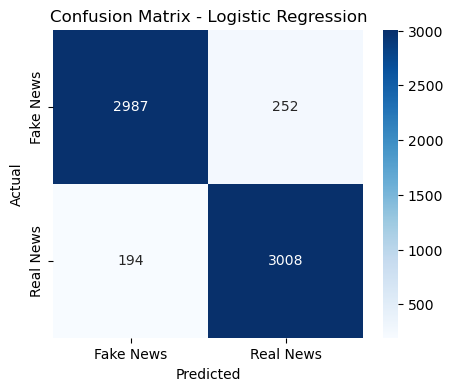

In [137]:
# Confusion Matrix (Heatmap)
import matplotlib.pyplot as plt
cm = confusion_matrix(y_test, y_pred_xgb_bow_best_3)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=["Fake News", "Real News"], yticklabels=["Fake News", "Real News"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Logistic Regression")
plt.show()